# Exploratory Data Analysis: Refined Scale-Up Solution Categories

This notebook analyzes the hierarchical classification of scale-up problem/solution pairs using the fine-grained ontology defined in `llm_evaluation_helper_v3.py`.

## Three-Level Ontology Structure
- **Level 1 (Domain)**: Chemical_Conditions, Workup_and_Purification, Specialized_Chemistries, Process_Engineering, Strategy_and_Optimization
- **Level 2 (Category)**: Reagents_Catalysts, Acid_Base_pH, Solvent_Phase, etc.
- **Level 3 (Leaf)**: Specific solution types (e.g., change_of_primary_reagent)

## Contents
1. Data Loading & Preprocessing
2. Problem Distribution Analysis
3. Refined Solution Categories Analysis (Three-Level Hierarchy)
4. Problem-Solution Co-occurrence Analysis

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

In [2]:
# Ensure output directories exist
import os
os.makedirs('figures', exist_ok=True)
os.makedirs('tables', exist_ok=True)
print("Output directories ready.")

Output directories ready.


## 1. Data Loading & Preprocessing

In [3]:
# Define three-level hierarchical ontology based on llm_evaluation_helper_v3.py
ONTOLOGY = {
    "Chemical_Conditions": {
        "Reagents_Catalysts": [
            "change_of_primary_reagent",
            "change_of_oxidant_or_oxidation_protocol",
            "change_of_reductant_or_reduction_protocol",
            "change_of_catalyst_or_ligand_identity",
            "optimization_of_catalyst_loading",
            "replacement_of_unstable_or_impure_reagent",
            "replacement_of_costly_or_low_purity_reagent",
            "reagent_change_to_reduce_waste_or_increase_green_score",
        ],
        "Acid_Base_pH": [
            "change_of_base",
            "change_of_acid",
            "optimization_of_acid_or_base_stoichiometry",
        ],
        "Solvent_Phase": [
            "solvent_change_for_reactivity",
            "solvent_change_for_solubility",
            "solvent_change_for_safety_or_green_chemistry",
            "solvent_change_to_reduce_side_products",
            "solvent_system_optimization_or_cosolvent_addition",
            "phase_behavior_or_biphasic_system_optimization",
        ],
        "Additives": [
            "change_of_additive",
        ],
        "Stoichiometry_Kinetics": [
            "optimization_of_reagent_stoichiometry",
            "change_of_addition_order_or_feed_profile",
            "temperature_setpoint_or_temperature_ramp_optimization",
            "pressure_or_gas_headspace_optimization",
            "hold_time_or_residence_time_optimization",
        ],
        "ProtectingGroups_Substrate": [
            "protecting_group_change_or_removal",
        ],
    },
    "Workup_and_Purification": {
        "Extraction_and_Workup": [
            "improved_quench_or_neutralization",
            "improved_impurity_purge_or_byproduct_control",
            "drying_or_isolation_process_optimization",
        ],
        "Crystallization": [
            "crystallization_solvent_or_antisolvent_optimization",
            "crystallization_nucleation_or_seed_control",
            "polymorph_or_solid_form_management",
        ],
        "Impurity_and_QC": [
            "feedstock_or_supplier_variability_management",
            "tolerance_of_reagent_or_feed_impurities",
            "improved_in_process_control_or_analytical_method",
        ],
    },
    "Specialized_Chemistries": {
        "Halogenation": [
            "optimization_of_halogenation_protocol",
        ],
        "Biocatalysis": [
            "biocatalytic_or_enzymatic_route_change_or_optimization",
        ],
    },
    "Process_Engineering": {
        "Reactor_and_Hardware": [
            "custom_or_novel_reactor_design",
            "improved_mixing_or_impeller_design",
            "improved_heat_transfer_or_temperature_control_hardware",
            "improved_photochemical_reactor_or_light_delivery",
            "improved_electrochemical_reactor_or_electrode_system",
        ],
        "Flow_and_Solids": [
            "batch_to_flow_or_flow_process_implementation",
            "packed_bed_or_fixed_bed_optimization",
            "clogging_or_fouling_mitigation",
            "slurry_handling_or_particle_size_optimization",
            "gas_evolution_or_mass_transfer_management",
            "continuous_process_intensification",
        ],
        "Atmosphere_and_Safety": [
            "optimization_of_inert_atmosphere_or_deoxygenation",
            "optimization_of_oxygen_or_gas_enriched_environment",
            "condition_change_to_reduce_or_remove_process_hazard",
            "thermal_runaway_mitigation_or_quench_safety_modification",
        ],
    },
    "Strategy_and_Optimization": {
        "Screening_Modeling": [
            "process_modeling_or_digital_twin_guided_change",
        ],
        "Route_Design": [
            "step_reordering_or_telescope_strategy",
            "entirely_new_route_or_step_replacement",
        ],
        "Fallback": [
            "insufficient_information_to_classify",
            "other",
        ],
    },
}

# Create reverse mappings for all three levels
LEAF_TO_CATEGORY = {}  # leaf -> category (level 2)
LEAF_TO_DOMAIN = {}    # leaf -> domain (level 1)
CATEGORY_TO_DOMAIN = {} # category -> domain

for domain, categories in ONTOLOGY.items():
    for category, leaves in categories.items():
        CATEGORY_TO_DOMAIN[category] = domain
        for leaf in leaves:
            LEAF_TO_CATEGORY[leaf] = category
            LEAF_TO_DOMAIN[leaf] = domain

# Count totals
total_domains = len(ONTOLOGY)
total_categories = sum(len(cats) for cats in ONTOLOGY.values())
total_leaves = len(LEAF_TO_CATEGORY)

print(f"Three-Level Ontology Statistics:")
print(f"  Level 1 (Domains): {total_domains}")
print(f"  Level 2 (Categories): {total_categories}")
print(f"  Level 3 (Leaves): {total_leaves}")

print(f"\nDomain breakdown:")
for domain, categories in ONTOLOGY.items():
    n_cats = len(categories)
    n_leaves = sum(len(leaves) for leaves in categories.values())
    print(f"  {domain}: {n_cats} categories, {n_leaves} leaves")

Three-Level Ontology Statistics:
  Level 1 (Domains): 5
  Level 2 (Categories): 17
  Level 3 (Leaves): 55

Domain breakdown:
  Chemical_Conditions: 6 categories, 24 leaves
  Workup_and_Purification: 3 categories, 9 leaves
  Specialized_Chemistries: 2 categories, 2 leaves
  Process_Engineering: 3 categories, 15 leaves
  Strategy_and_Optimization: 3 categories, 5 leaves


In [4]:
# Load original data with problem descriptions
original_df = pd.read_json('../figure3/results.jsonl', lines=True)
print(f"Original data shape: {original_df.shape}")
print(f"Columns: {original_df.columns.tolist()}")
original_df.head(2)

Original data shape: (11475, 10)
Columns: ['Paper ID', 'Paper URL', 'Paper Title', 'Pair Number', 'Problems', 'Problem_Description', 'Solutions', 'Solution_Description', 'Supporting_Evidence', 'missing_information']


,Paper ID,Paper URL,Paper Title,Pair Number,Problems,Problem_Description,Solutions,Solution_Description,Supporting_Evidence,missing_information
0,acs.oprd.0c00004,https://doi.org/10.1021/acs.oprd.0c00004,Reiterative Chiral Resolution/Racemization/Rec...,1,"[[LOW YIELD], [LOW YIELD]]",The organocatalytic cascade deprotection/intra...,"[[CATALYST OPTIMIZATION], [CATALYST OPTIMIZATI...",Replacing the expensive CPA I with cheap l‑(+)...,“Acceptable yields were obtained only when at ...,"[COST, SAFETY, AVAILABILITY]"
1,acs.oprd.0c00004,https://doi.org/10.1021/acs.oprd.0c00004,Reiterative Chiral Resolution/Racemization/Rec...,2,[[COST]],The original process isolated the target enant...,"[[NEW_PURIFICATION PROCEDURE], [SOLVENT CHANGE]]",A fractional‑crystallization resolution using ...,“Supercritical fluid chromatography (SFC) was ...,"[COST, SAFETY, AVAILABILITY]"


In [5]:
# Load refined classification results
refined_df = pd.read_json('scaleup_all_120b_20251229_results.jsonl', lines=True)
print(f"Refined data shape: {refined_df.shape}")
print(f"Columns: {refined_df.columns.tolist()}")
refined_df.head(2)

Refined data shape: (11468, 10)
Columns: ['row_index', 'primary_category', 'primary_description', 'primary_confidence', 'primary_reasoning', 'verifier_agree', 'verifier_category', 'verifier_description', 'verifier_confidence', 'verifier_comment']


,row_index,primary_category,primary_description,primary_confidence,primary_reasoning,verifier_agree,verifier_category,verifier_description,verifier_confidence,verifier_comment
0,6,entirely_new_route_or_step_replacement,"The original Mori route was lengthy, used geno...",high,The solution replaces the previous multi‑step ...,True,entirely_new_route_or_step_replacement,"The original Mori synthesis required 14 steps,...",high,None
1,11,change_of_reductant_or_reduction_protocol,"The original nitro‑reduction step using FeSO₄,...",high,The solution’s primary change is the replaceme...,True,change_of_reductant_or_reduction_protocol,"The original nitro‑reduction step using FeSO₄,...",high,None


In [6]:
# Merge the datasets
merged_df = original_df.merge(
    refined_df,
    left_index=True,
    right_on='row_index',
    how='inner'
)
print(f"Merged data shape: {merged_df.shape}")

# Add hierarchical columns for all three levels
merged_df['solution_domain'] = merged_df['verifier_category'].map(LEAF_TO_DOMAIN)      # Level 1
merged_df['solution_category'] = merged_df['verifier_category'].map(LEAF_TO_CATEGORY)  # Level 2
merged_df['solution_leaf'] = merged_df['verifier_category']                             # Level 3

# Check for any unmapped categories
unmapped = merged_df[merged_df['solution_domain'].isna()]['verifier_category'].unique()
if len(unmapped) > 0:
    print(f"Warning: Unmapped categories found: {unmapped}")
else:
    print("All categories mapped successfully to three-level hierarchy!")

# Show sample of hierarchy
print("\nSample of three-level hierarchy mapping:")
merged_df[['verifier_category', 'solution_leaf', 'solution_category', 'solution_domain']].head(10)

Merged data shape: (11468, 20)
All categories mapped successfully to three-level hierarchy!

Sample of three-level hierarchy mapping:


,verifier_category,solution_leaf,solution_category,solution_domain
14,change_of_acid,change_of_acid,Acid_Base_pH,Chemical_Conditions
5,entirely_new_route_or_step_replacement,entirely_new_route_or_step_replacement,Route_Design,Strategy_and_Optimization
18,crystallization_solvent_or_antisolvent_optimiz...,crystallization_solvent_or_antisolvent_optimiz...,Crystallization,Workup_and_Purification
19,solvent_change_for_reactivity,solvent_change_for_reactivity,Solvent_Phase,Chemical_Conditions
29,step_reordering_or_telescope_strategy,step_reordering_or_telescope_strategy,Route_Design,Strategy_and_Optimization
9858,temperature_setpoint_or_temperature_ramp_optim...,temperature_setpoint_or_temperature_ramp_optim...,Stoichiometry_Kinetics,Chemical_Conditions
0,entirely_new_route_or_step_replacement,entirely_new_route_or_step_replacement,Route_Design,Strategy_and_Optimization
40,solvent_change_for_reactivity,solvent_change_for_reactivity,Solvent_Phase,Chemical_Conditions
8,improved_impurity_purge_or_byproduct_control,improved_impurity_purge_or_byproduct_control,Extraction_and_Workup,Workup_and_Purification
11,solvent_change_to_reduce_side_products,solvent_change_to_reduce_side_products,Solvent_Phase,Chemical_Conditions


In [7]:
# Extract and flatten problem categories
def extract_problems(problems_list):
    """Extract problem tags from the Problems column."""
    if isinstance(problems_list, list):
        # Remove brackets and get unique problems
        problems = set()
        for p in problems_list:
            if isinstance(p, str):
                # Clean up the tag
                clean_p = p.strip('[]').upper()
                problems.add(clean_p)
        return list(problems)
    return []

merged_df['problem_tags'] = merged_df['Problems'].apply(extract_problems)

# Show sample
merged_df[['Problems', 'problem_tags']].head()

,Problems,problem_tags
14,"[[LOW YIELD], [LOW YIELD]]",[LOW YIELD]
5,[[COST]],[COST]
18,"[[SOLUBILITY], [PURIFICATION]]","[PURIFICATION, SOLUBILITY]"
19,"[[DECOMPOSITION], [LONG_REACTIONS]]","[DECOMPOSITION, LONG_REACTIONS]"
29,"[[PURIFICATION], [LOW YIELD]]","[PURIFICATION, LOW YIELD]"


## 2. Problem Distribution Analysis

In [8]:
# Count problem occurrences
all_problems = []
for tags in merged_df['problem_tags']:
    all_problems.extend(tags)

problem_counts = Counter(all_problems)
problem_df = pd.DataFrame.from_dict(problem_counts, orient='index', columns=['count'])
problem_df = problem_df.sort_values('count', ascending=False)
problem_df['percentage'] = (problem_df['count'] / len(merged_df) * 100).round(1)

print(f"Total problem-solution pairs: {len(merged_df)}")
print(f"Unique problem types: {len(problem_df)}")
print("\nProblem distribution:")
problem_df

Total problem-solution pairs: 11468
Unique problem types: 11

Problem distribution:


,count,percentage
LOW YIELD,4087,35.6
SAFETY,2932,25.6
PURIFICATION,2892,25.2
MIXABILITY,2199,19.2
VARIABILITY,2116,18.5
DECOMPOSITION,1834,16.0
COST,1826,15.9
LONG_REACTIONS,1288,11.2
SOLUBILITY,1231,10.7
EXOTHERMIC,1086,9.5


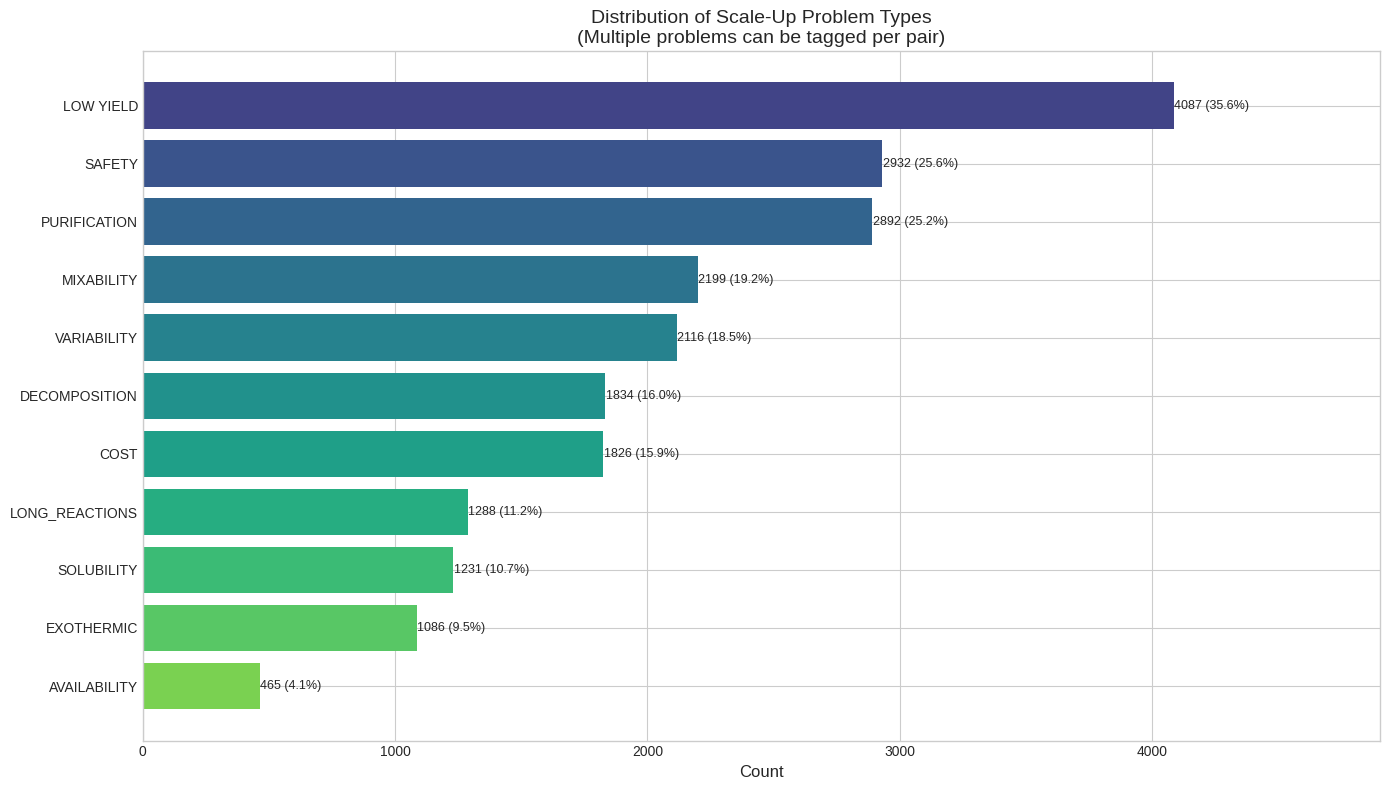

In [9]:
# Visualize problem distribution
fig, ax = plt.subplots(figsize=(14, 8))

colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(problem_df)))
bars = ax.barh(problem_df.index[::-1], problem_df['count'][::-1], color=colors[::-1])

# Add count labels
for bar, count, pct in zip(bars, problem_df['count'][::-1], problem_df['percentage'][::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{count} ({pct}%)', va='center', fontsize=9)

ax.set_xlabel('Count')
ax.set_title('Distribution of Scale-Up Problem Types\n(Multiple problems can be tagged per pair)', fontsize=14)
ax.set_xlim(0, problem_df['count'].max() * 1.2)

plt.tight_layout()
plt.savefig('figures/problem_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

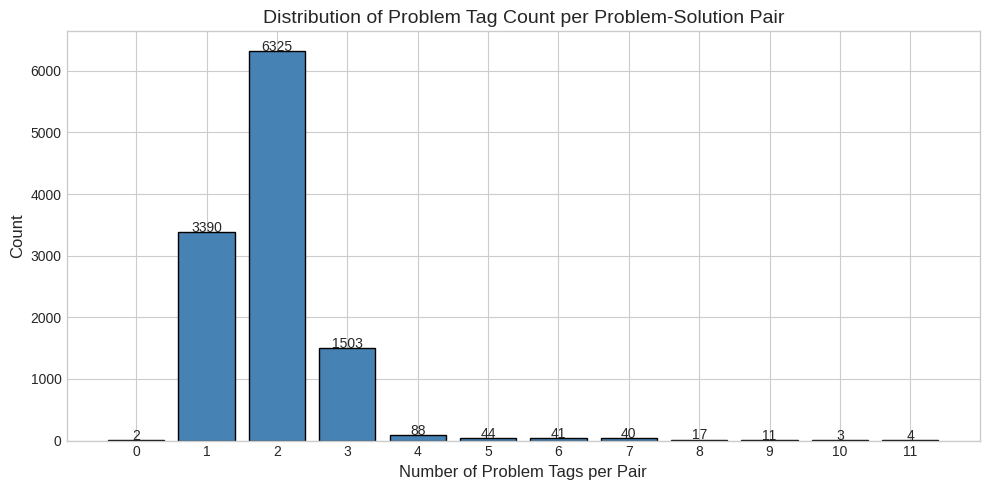

In [10]:
# Number of problems per pair
merged_df['num_problems'] = merged_df['problem_tags'].apply(len)

fig, ax = plt.subplots(figsize=(10, 5))
problem_count_dist = merged_df['num_problems'].value_counts().sort_index()
ax.bar(problem_count_dist.index, problem_count_dist.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Number of Problem Tags per Pair')
ax.set_ylabel('Count')
ax.set_title('Distribution of Problem Tag Count per Problem-Solution Pair')
ax.set_xticks(problem_count_dist.index)

for i, v in enumerate(problem_count_dist.values):
    ax.text(problem_count_dist.index[i], v + 1, str(v), ha='center')

plt.tight_layout()
plt.savefig('figures/problem_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Refined Solution Categories Analysis (Three-Level Hierarchy)

The ontology has three levels:
1. **Domain** (Level 1): High-level groupings (Chemical_Conditions, Process_Engineering, etc.)
2. **Category** (Level 2): Mid-level groupings within domains (Reagents_Catalysts, Solvent_Phase, etc.)
3. **Leaf** (Level 3): Specific solution types (change_of_primary_reagent, etc.)

### 3.1 Domain Distribution (Level 1)

In [11]:
# Domain distribution (Level 1 - top of hierarchy)
domain_counts = merged_df['solution_domain'].value_counts()
domain_df = pd.DataFrame({
    'count': domain_counts,
    'percentage': (domain_counts / len(merged_df) * 100).round(1)
})

print("Solution Domains (Level 1 - Top of Hierarchy):")
domain_df

Solution Domains (Level 1 - Top of Hierarchy):


,count,percentage
solution_domain,,
Chemical_Conditions,6777,59.1
Process_Engineering,1829,15.9
Workup_and_Purification,1473,12.8
Strategy_and_Optimization,1210,10.6
Specialized_Chemistries,179,1.6


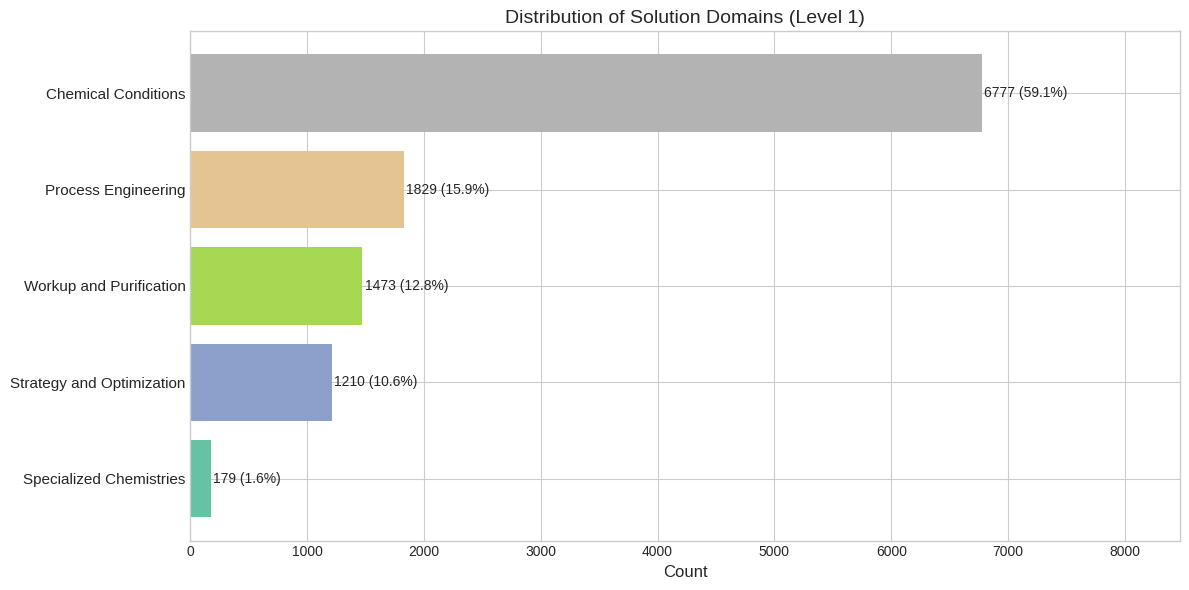

In [12]:
# Visualize domain distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by count
domain_df_sorted = domain_df.sort_values('count', ascending=True)

# Use a nice color palette
colors = plt.cm.Set2(np.linspace(0, 1, len(domain_df_sorted)))
bars = ax.barh(range(len(domain_df_sorted)), domain_df_sorted['count'], color=colors)

ax.set_yticks(range(len(domain_df_sorted)))
ax.set_yticklabels([d.replace('_', ' ') for d in domain_df_sorted.index], fontsize=11)

# Add count labels
for i, (count, pct) in enumerate(zip(domain_df_sorted['count'], domain_df_sorted['percentage'])):
    ax.text(count + 20, i, f'{count} ({pct}%)', va='center', fontsize=10)

ax.set_xlabel('Count', fontsize=12)
ax.set_title('Distribution of Solution Domains (Level 1)', fontsize=14)
ax.set_xlim(0, domain_df_sorted['count'].max() * 1.25)

plt.tight_layout()
plt.savefig('figures/solution_domain_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

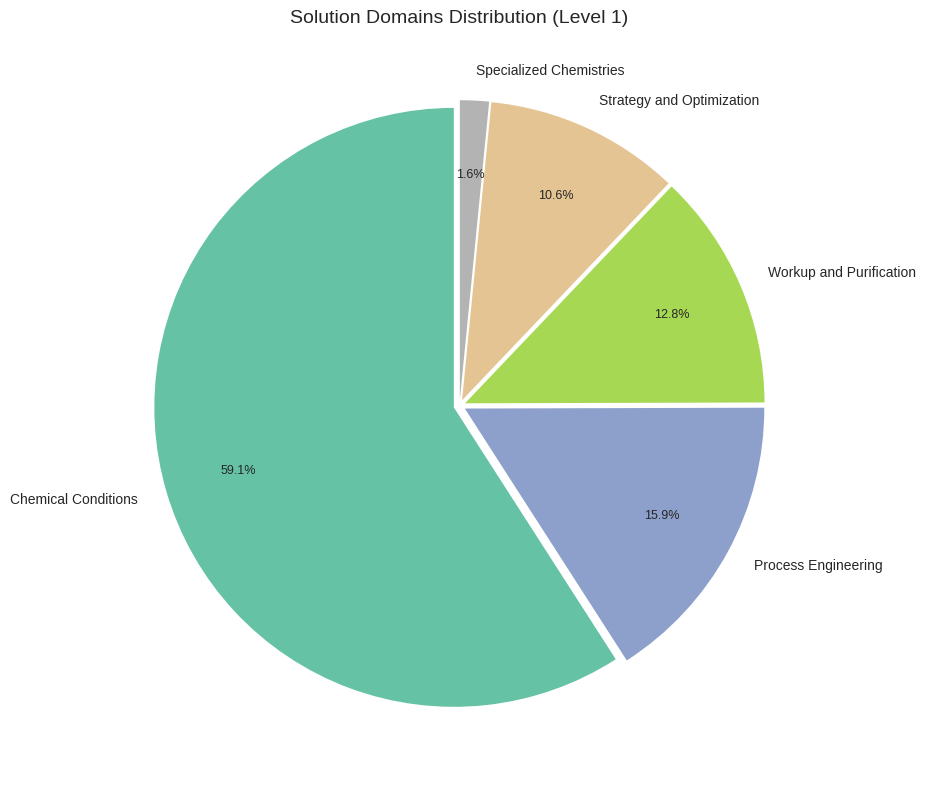

In [13]:
# Pie chart for domains
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.Set2(np.linspace(0, 1, len(domain_df)))
labels = [d.replace('_', ' ') for d in domain_df.index]

wedges, texts, autotexts = ax.pie(
    domain_df['count'],
    labels=labels,
    autopct='%1.1f%%',
    colors=colors,
    pctdistance=0.75,
    startangle=90,
    explode=[0.02] * len(domain_df)
)

# Adjust label positions
for text in texts:
    text.set_fontsize(10)
for autotext in autotexts:
    autotext.set_fontsize(9)

ax.set_title('Solution Domains Distribution (Level 1)', fontsize=14)

plt.tight_layout()
plt.savefig('figures/solution_domain_pie.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Category Distribution (Level 2)

In [14]:
# Category distribution (Level 2)
category_counts = merged_df['solution_category'].value_counts()
category_df = pd.DataFrame({
    'count': category_counts,
    'percentage': (category_counts / len(merged_df) * 100).round(1),
    'domain': [CATEGORY_TO_DOMAIN.get(cat, 'Unknown') for cat in category_counts.index]
})

print(f"Total unique categories (Level 2): {len(category_df)}")
print("\nCategory Distribution:")
category_df

Total unique categories (Level 2): 17

Category Distribution:


,count,percentage,domain
solution_category,,,
Reagents_Catalysts,2075,18.1,Chemical_Conditions
Stoichiometry_Kinetics,1834,16.0,Chemical_Conditions
Solvent_Phase,1509,13.2,Chemical_Conditions
Route_Design,955,8.3,Strategy_and_Optimization
Flow_and_Solids,874,7.6,Process_Engineering
Extraction_and_Workup,790,6.9,Workup_and_Purification
Acid_Base_pH,787,6.9,Chemical_Conditions
Reactor_and_Hardware,694,6.1,Process_Engineering
Crystallization,498,4.3,Workup_and_Purification


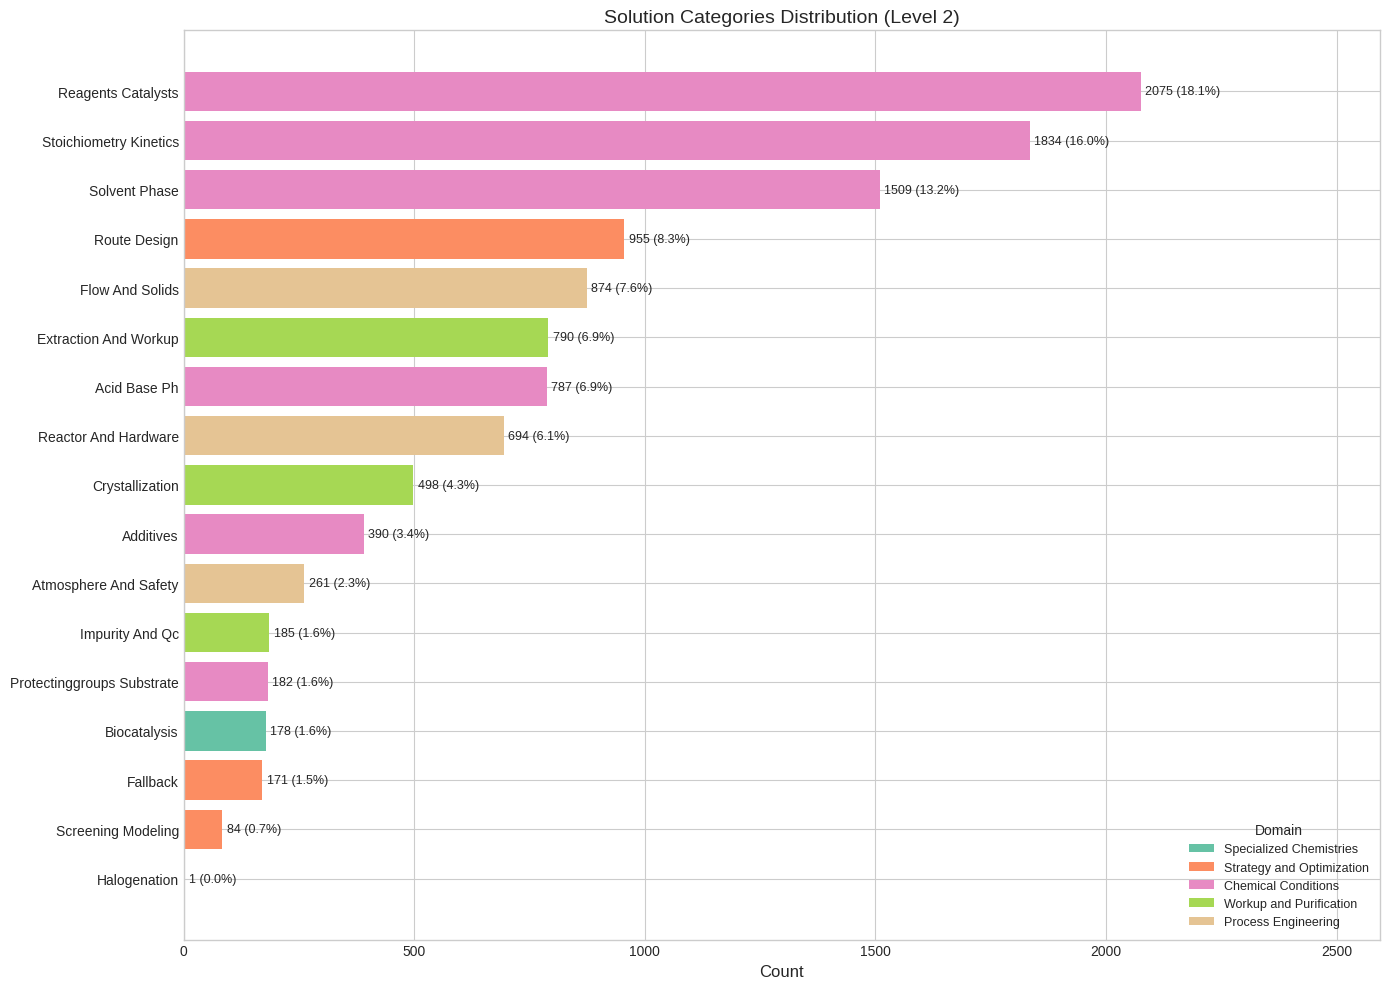

In [15]:
# Visualize category distribution colored by domain
fig, ax = plt.subplots(figsize=(14, 10))

# Sort by count
category_df_sorted = category_df.sort_values('count', ascending=True)

# Color by domain
unique_domains = category_df_sorted['domain'].unique()
domain_colors = {d: plt.cm.Set2(i/len(unique_domains)) for i, d in enumerate(unique_domains)}
colors = [domain_colors[d] for d in category_df_sorted['domain']]

bars = ax.barh(range(len(category_df_sorted)), category_df_sorted['count'], color=colors)

# Clean category names for display
labels = [cat.replace('_', ' ').title() for cat in category_df_sorted.index]
ax.set_yticks(range(len(category_df_sorted)))
ax.set_yticklabels(labels, fontsize=10)

# Add count labels
for i, (count, pct) in enumerate(zip(category_df_sorted['count'], category_df_sorted['percentage'])):
    ax.text(count + 10, i, f'{count} ({pct}%)', va='center', fontsize=9)

ax.set_xlabel('Count', fontsize=12)
ax.set_title('Solution Categories Distribution (Level 2)', fontsize=14)
ax.set_xlim(0, category_df_sorted['count'].max() * 1.25)

# Add legend for domains
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=domain_colors[d], label=d.replace('_', ' ')) for d in unique_domains]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Domain')

plt.tight_layout()
plt.savefig('figures/solution_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Leaf Distribution (Level 3)

In [16]:
# Leaf distribution (Level 3)
leaf_counts = merged_df['solution_leaf'].value_counts()
leaf_df = pd.DataFrame({
    'count': leaf_counts,
    'percentage': (leaf_counts / len(merged_df) * 100).round(1),
    'category': [LEAF_TO_CATEGORY.get(leaf, 'Unknown') for leaf in leaf_counts.index],
    'domain': [LEAF_TO_DOMAIN.get(leaf, 'Unknown') for leaf in leaf_counts.index]
})

print(f"Total unique leaf categories (Level 3): {len(leaf_df)}")
print("\nTop 25 Leaf Categories:")
leaf_df.head(25)

Total unique leaf categories (Level 3): 55

Top 25 Leaf Categories:


,count,percentage,category,domain
solution_leaf,,,,
change_of_primary_reagent,688,6.0,Reagents_Catalysts,Chemical_Conditions
entirely_new_route_or_step_replacement,639,5.6,Route_Design,Strategy_and_Optimization
temperature_setpoint_or_temperature_ramp_optimization,625,5.4,Stoichiometry_Kinetics,Chemical_Conditions
solvent_change_for_solubility,601,5.2,Solvent_Phase,Chemical_Conditions
change_of_addition_order_or_feed_profile,533,4.6,Stoichiometry_Kinetics,Chemical_Conditions
change_of_catalyst_or_ligand_identity,490,4.3,Reagents_Catalysts,Chemical_Conditions
change_of_base,448,3.9,Acid_Base_pH,Chemical_Conditions
optimization_of_reagent_stoichiometry,405,3.5,Stoichiometry_Kinetics,Chemical_Conditions
change_of_additive,390,3.4,Additives,Chemical_Conditions


In [17]:
# Full three-level nested breakdown
def create_three_level_breakdown(df):
    """Create a complete three-level breakdown of the ontology."""
    breakdown = {}

    for domain in df['solution_domain'].dropna().unique():
        domain_data = df[df['solution_domain'] == domain]
        breakdown[domain] = {
            'total': len(domain_data),
            'categories': {}
        }

        for category in domain_data['solution_category'].unique():
            cat_data = domain_data[domain_data['solution_category'] == category]
            leaf_counts = cat_data['solution_leaf'].value_counts().to_dict()
            breakdown[domain]['categories'][category] = {
                'total': len(cat_data),
                'leaves': leaf_counts
            }

    return breakdown

nested_breakdown = create_three_level_breakdown(merged_df)

# Display as formatted table
for domain in sorted(nested_breakdown.keys(), key=lambda x: -nested_breakdown[x]['total']):
    domain_data = nested_breakdown[domain]
    print(f"\n{'='*80}")
    print(f"DOMAIN: {domain.replace('_', ' ')}")
    print(f"Total: {domain_data['total']} ({domain_data['total']/len(merged_df)*100:.1f}%)")
    print('='*80)

    for category in sorted(domain_data['categories'].keys(),
                          key=lambda x: -domain_data['categories'][x]['total']):
        cat_data = domain_data['categories'][category]
        print(f"\n  CATEGORY: {category.replace('_', ' ')}: {cat_data['total']} ({cat_data['total']/len(merged_df)*100:.1f}%)")
        print('  ' + '-'*60)

        for leaf, count in sorted(cat_data['leaves'].items(), key=lambda x: -x[1]):
            clean_leaf = leaf.replace('_', ' ')
            print(f"    • {clean_leaf}: {count} ({count/len(merged_df)*100:.1f}%)")


DOMAIN: Chemical Conditions
Total: 6777 (59.1%)

  CATEGORY: Reagents Catalysts: 2075 (18.1%)
  ------------------------------------------------------------
    • change of primary reagent: 688 (6.0%)
    • change of catalyst or ligand identity: 490 (4.3%)
    • optimization of catalyst loading: 205 (1.8%)
    • change of oxidant or oxidation protocol: 194 (1.7%)
    • replacement of costly or low purity reagent: 153 (1.3%)
    • change of reductant or reduction protocol: 150 (1.3%)
    • replacement of unstable or impure reagent: 125 (1.1%)
    • reagent change to reduce waste or increase green score: 70 (0.6%)

  CATEGORY: Stoichiometry Kinetics: 1834 (16.0%)
  ------------------------------------------------------------
    • temperature setpoint or temperature ramp optimization: 625 (5.4%)
    • change of addition order or feed profile: 533 (4.6%)
    • optimization of reagent stoichiometry: 405 (3.5%)
    • hold time or residence time optimization: 179 (1.6%)
    • pressure or ga

### 3.4 Three-Level Hierarchy Visualization (Sunburst)

In [18]:
# Create sunburst chart using plotly (if available) or alternative visualization
try:
    import plotly.express as px

    # Prepare data for sunburst
    sunburst_data = []
    for _, row in merged_df.iterrows():
        sunburst_data.append({
            'domain': row['solution_domain'].replace('_', ' ') if pd.notna(row['solution_domain']) else 'Unknown',
            'category': row['solution_category'].replace('_', ' ') if pd.notna(row['solution_category']) else 'Unknown',
            'leaf': row['solution_leaf'].replace('_', ' ')[:40] if pd.notna(row['solution_leaf']) else 'Unknown',
        })

    sunburst_df = pd.DataFrame(sunburst_data)

    # Count occurrences
    counts_df = sunburst_df.groupby(['domain', 'category', 'leaf']).size().reset_index(name='count')

    fig = px.sunburst(
        counts_df,
        path=['domain', 'category', 'leaf'],
        values='count',
        title='Three-Level Ontology: Domain → Category → Leaf',
        width=900,
        height=900
    )
    fig.update_traces(textinfo="label+percent parent")
    fig.write_html('figures/ontology_sunburst.html')
    fig.show()
    print("Interactive sunburst saved to figures/ontology_sunburst.html")

except ImportError:
    print("Plotly not available. Creating alternative visualization...")

    # Alternative: Grouped bar chart showing categories within domains
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()

    domains_sorted = sorted(nested_breakdown.keys(),
                           key=lambda x: -nested_breakdown[x]['total'])

    for idx, domain in enumerate(domains_sorted[:6]):
        ax = axes[idx]
        domain_data = nested_breakdown[domain]

        # Get categories and their totals
        cats = list(domain_data['categories'].keys())
        totals = [domain_data['categories'][c]['total'] for c in cats]

        # Sort by total
        sorted_pairs = sorted(zip(cats, totals), key=lambda x: -x[1])
        cats, totals = zip(*sorted_pairs) if sorted_pairs else ([], [])

        # Clean names
        clean_cats = [c.replace('_', '\n') for c in cats]

        colors = plt.cm.Set3(np.linspace(0, 1, len(cats)))
        bars = ax.bar(range(len(cats)), totals, color=colors)

        ax.set_xticks(range(len(cats)))
        ax.set_xticklabels(clean_cats, rotation=45, ha='right', fontsize=8)
        ax.set_title(f"{domain.replace('_', ' ')}\n(n={domain_data['total']})", fontsize=10)
        ax.set_ylabel('Count')

        # Add labels
        for bar, count in zip(bars, totals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    str(count), ha='center', fontsize=8)

    # Hide unused axes
    for idx in range(len(domains_sorted), 6):
        if idx < len(axes):
            axes[idx].set_visible(False)

    plt.suptitle('Categories Within Each Domain (Level 1 → Level 2)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig('figures/domain_category_breakdown.png', dpi=150, bbox_inches='tight')
    plt.show()

Interactive sunburst saved to figures/ontology_sunburst.html


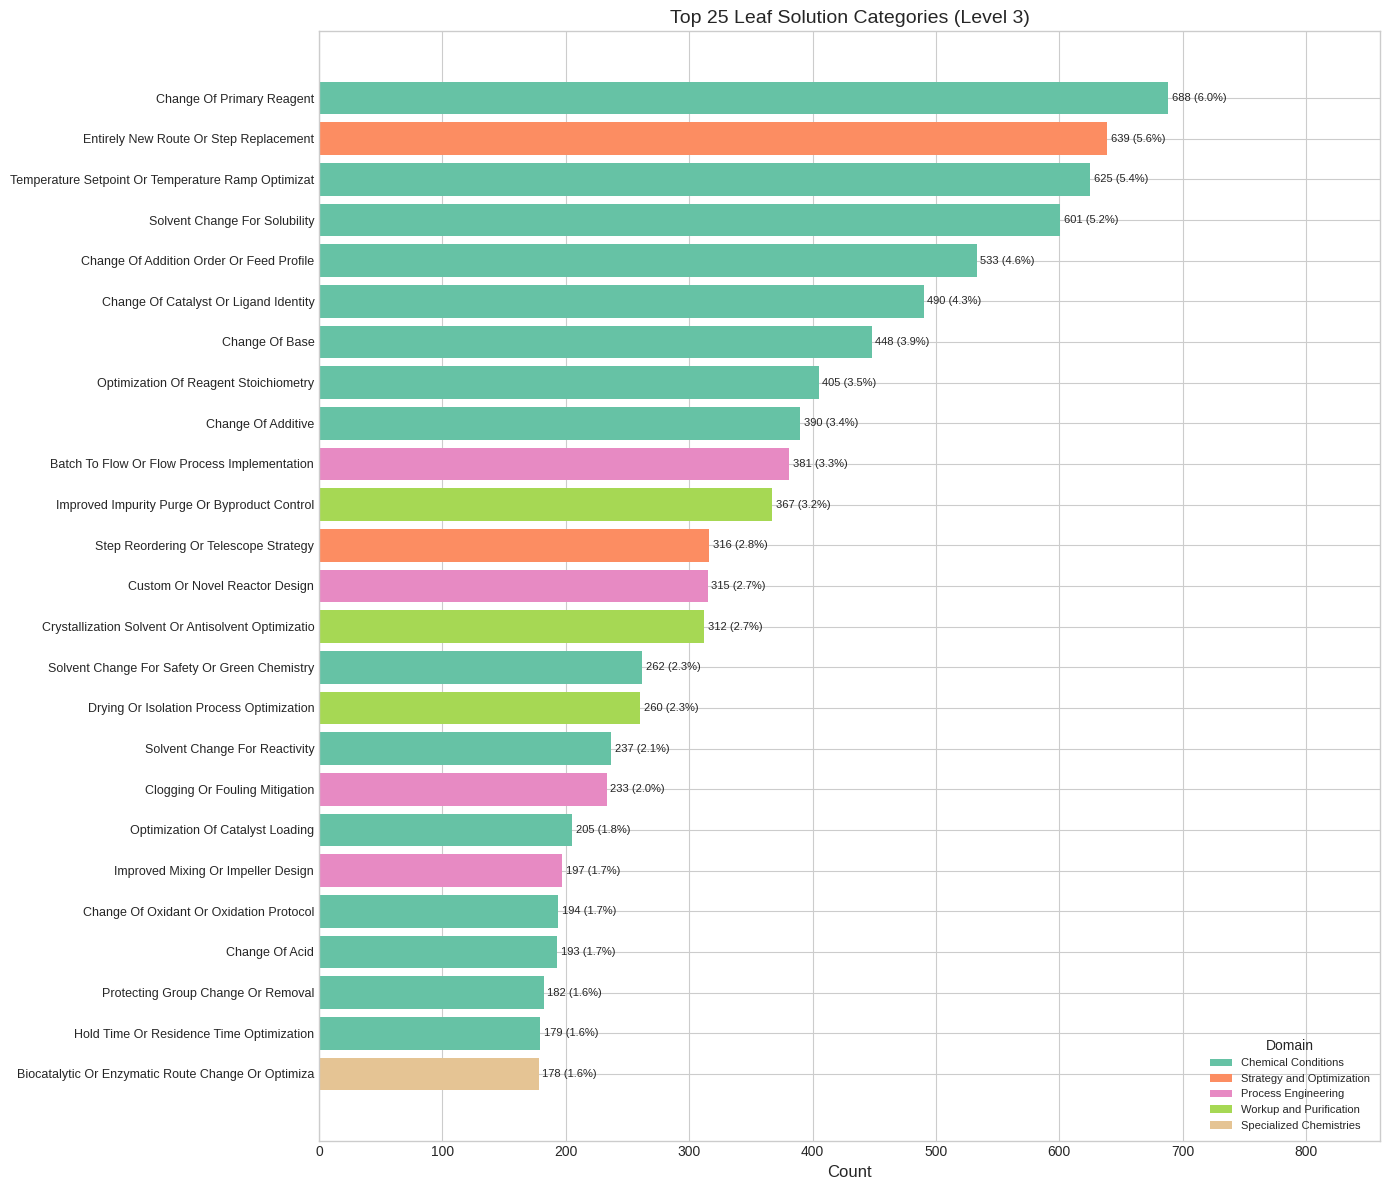

In [19]:
# Visualize top 25 leaf categories colored by domain
fig, ax = plt.subplots(figsize=(14, 12))

top_n = 25
top_leaves = leaf_df.head(top_n).copy()

# Color by domain
unique_domains = top_leaves['domain'].unique()
domain_colors = {d: plt.cm.Set2(i/len(unique_domains)) for i, d in enumerate(unique_domains)}
colors = [domain_colors[d] for d in top_leaves['domain'][::-1]]

bars = ax.barh(
    range(len(top_leaves)),
    top_leaves['count'][::-1].values,
    color=colors
)

# Clean leaf names for display
labels = [leaf.replace('_', ' ').title()[:50] for leaf in top_leaves.index[::-1]]
ax.set_yticks(range(len(top_leaves)))
ax.set_yticklabels(labels, fontsize=9)

# Add count labels
for i, (count, pct) in enumerate(zip(top_leaves['count'][::-1], top_leaves['percentage'][::-1])):
    ax.text(count + 3, i, f'{count} ({pct}%)', va='center', fontsize=8)

ax.set_xlabel('Count')
ax.set_title(f'Top {top_n} Leaf Solution Categories (Level 3)', fontsize=14)
ax.set_xlim(0, top_leaves['count'].max() * 1.25)

# Add legend for domains
legend_elements = [Patch(facecolor=domain_colors[d], label=d.replace('_', ' ')) for d in unique_domains]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, title='Domain')

plt.tight_layout()
plt.savefig('figures/solution_leaf_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Classifier vs Verifier Agreement

In [20]:
# Analyze classifier-verifier agreement
agreement_rate = merged_df['verifier_agree'].mean()
print(f"Classifier-Verifier Agreement Rate: {agreement_rate*100:.1f}%")

# Breakdown by confidence
confidence_agreement = merged_df.groupby('verifier_confidence').agg({
    'verifier_agree': ['mean', 'count']
}).round(3)
confidence_agreement.columns = ['agreement_rate', 'count']
print("\nAgreement by Verifier Confidence:")
confidence_agreement

Classifier-Verifier Agreement Rate: 92.9%

Agreement by Verifier Confidence:


,agreement_rate,count
verifier_confidence,,
high,0.935,11398
medium,0.000,70


In [21]:
# When verifier disagrees, what are the corrections?
disagreements = merged_df[merged_df['verifier_agree'] == False].copy()
print(f"Total disagreements: {len(disagreements)}")

if len(disagreements) > 0:
    print("\nDisagreement cases:")
    for _, row in disagreements.iterrows():
        print(f"\n  Primary: {row['primary_category']}")
        print(f"  Verifier: {row['verifier_category']}")
        if row['verifier_comment']:
            print(f"  Comment: {row['verifier_comment'][:100]}...")

Total disagreements: 815

Disagreement cases:

  Primary: crystallization_solvent_or_antisolvent_optimization
  Verifier: entirely_new_route_or_step_replacement
  Comment: The change replaces an entire purification step rather than merely adjusting crystallization solvent...

  Primary: entirely_new_route_or_step_replacement
  Verifier: biocatalytic_or_enzymatic_route_change_or_optimization
  Comment: The key change is the introduction of a new enzymatic step, which fits the biocatalytic route change...

  Primary: solvent_change_for_safety_or_green_chemistry
  Verifier: thermal_runaway_mitigation_or_quench_safety_modification
  Comment: The primary driver is mitigation of a thermal runaway hazard, which matches the dedicated category f...

  Primary: solvent_change_for_solubility
  Verifier: batch_to_flow_or_flow_process_implementation
  Comment: The key change is the transition from a dilute batch process to a continuous‑flow in‑situ generation...

  Primary: change_of_catalyst_or_li

## 4. Problem-Solution Co-occurrence Analysis

### 4.1 Problem to Solution Domain Co-occurrence (Level 1)

In [22]:
# Create problem-solution co-occurrence matrix
def create_cooccurrence_matrix(df, problem_col, solution_col):
    """Create a co-occurrence matrix between problems and solutions."""
    problem_set = set()
    for tags in df[problem_col]:
        problem_set.update(tags)

    solution_set = df[solution_col].dropna().unique()

    matrix = pd.DataFrame(0, index=sorted(problem_set), columns=sorted(solution_set))

    for _, row in df.iterrows():
        if pd.notna(row[solution_col]):
            for problem in row[problem_col]:
                matrix.loc[problem, row[solution_col]] += 1

    return matrix

# Problem to Solution Domain (Level 1)
cooc_domain = create_cooccurrence_matrix(merged_df, 'problem_tags', 'solution_domain')

# Filter to show only non-empty rows/columns
cooc_domain = cooc_domain.loc[cooc_domain.sum(axis=1) > 0, cooc_domain.sum(axis=0) > 0]

print(f"Co-occurrence matrix shape (Problem × Domain): {cooc_domain.shape}")
cooc_domain

Co-occurrence matrix shape (Problem × Domain): (11, 5)


,Chemical_Conditions,Process_Engineering,Specialized_Chemistries,Strategy_and_Optimization,Workup_and_Purification
AVAILABILITY,239,63,17,117,29
COST,1172,136,62,342,114
DECOMPOSITION,1223,240,29,175,167
EXOTHERMIC,586,384,2,76,38
LONG_REACTIONS,713,271,22,198,84
LOW YIELD,2755,430,93,507,302
MIXABILITY,1196,686,19,119,179
PURIFICATION,1402,152,33,371,934
SAFETY,1659,668,32,347,226
SOLUBILITY,857,133,9,83,149


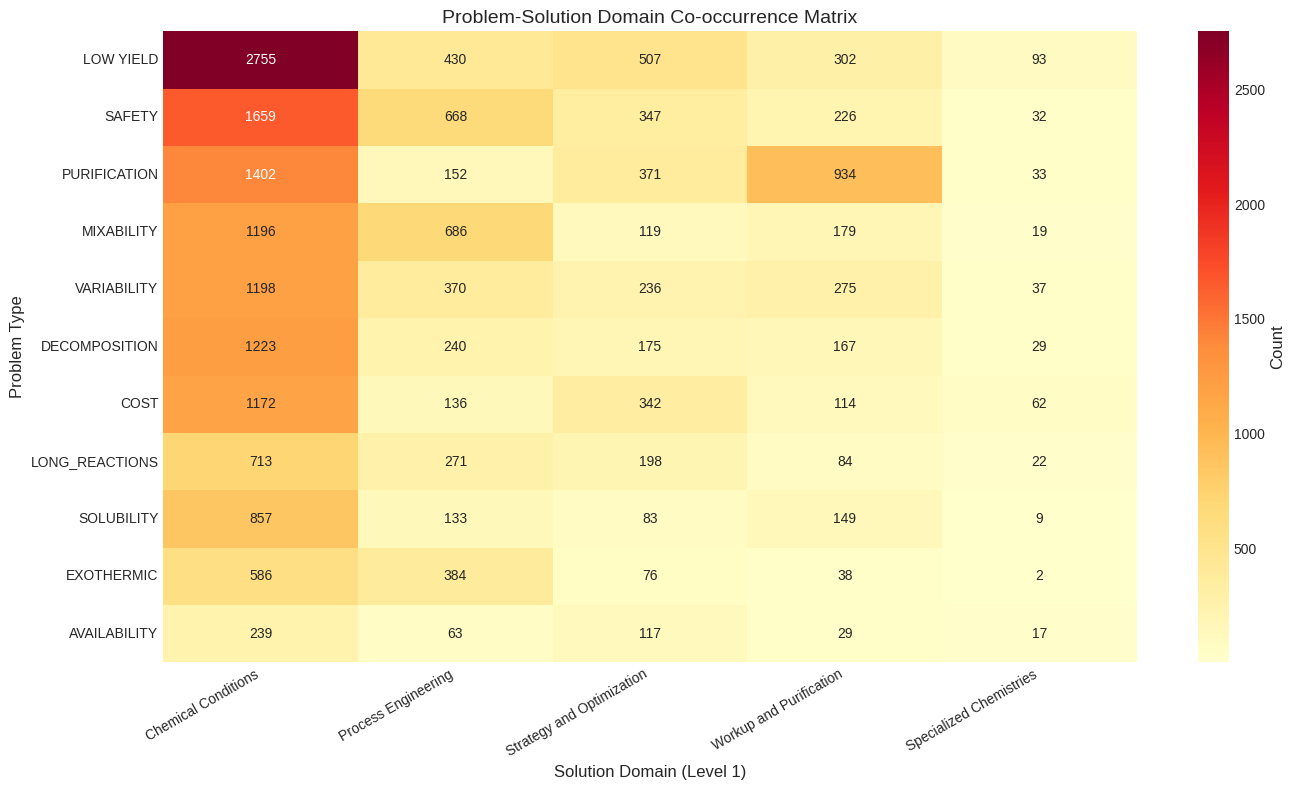

In [23]:
# Heatmap: Problem to Solution Domain
fig, ax = plt.subplots(figsize=(14, 8))

# Sort by totals
row_order = cooc_domain.sum(axis=1).sort_values(ascending=False).index
col_order = cooc_domain.sum(axis=0).sort_values(ascending=False).index
cooc_sorted = cooc_domain.loc[row_order, col_order]

# Clean column names
cooc_sorted.columns = [c.replace('_', ' ') for c in cooc_sorted.columns]

sns.heatmap(
    cooc_sorted,
    annot=True,
    fmt='d',
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Count'},
    annot_kws={'size': 10}
)

ax.set_xlabel('Solution Domain (Level 1)', fontsize=12)
ax.set_ylabel('Problem Type', fontsize=12)
ax.set_title('Problem-Solution Domain Co-occurrence Matrix', fontsize=14)

# Rotate labels for readability
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.savefig('figures/problem_solution_domain_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Problem to Solution Category Co-occurrence (Level 2)

In [24]:
# For each domain, show problem to category co-occurrence
def plot_domain_category_cooccurrence(df, domain_name, min_count=2):
    """Plot co-occurrence for categories within a specific domain."""
    domain_df = df[df['solution_domain'] == domain_name]

    if len(domain_df) < min_count:
        print(f"Skipping {domain_name}: only {len(domain_df)} entries")
        return None

    cooc = create_cooccurrence_matrix(domain_df, 'problem_tags', 'solution_category')
    cooc = cooc.loc[cooc.sum(axis=1) > 0, cooc.sum(axis=0) > 0]

    if cooc.shape[0] == 0 or cooc.shape[1] == 0:
        return None

    fig, ax = plt.subplots(figsize=(max(10, cooc.shape[1]*1.8), max(6, cooc.shape[0]*0.6)))

    # Sort
    row_order = cooc.sum(axis=1).sort_values(ascending=False).index
    col_order = cooc.sum(axis=0).sort_values(ascending=False).index
    cooc = cooc.loc[row_order, col_order]

    # Clean column names
    clean_cols = [c.replace('_', ' ').title() for c in cooc.columns]
    cooc.columns = clean_cols

    sns.heatmap(
        cooc,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        cbar_kws={'label': 'Count'},
        annot_kws={'size': 9}
    )

    ax.set_xlabel('Solution Category (Level 2)', fontsize=11)
    ax.set_ylabel('Problem Type', fontsize=11)
    ax.set_title(f'Problem → Category Co-occurrence: {domain_name.replace("_", " ")}\n(n={len(domain_df)})', fontsize=12)

    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=10)

    plt.tight_layout()
    return fig

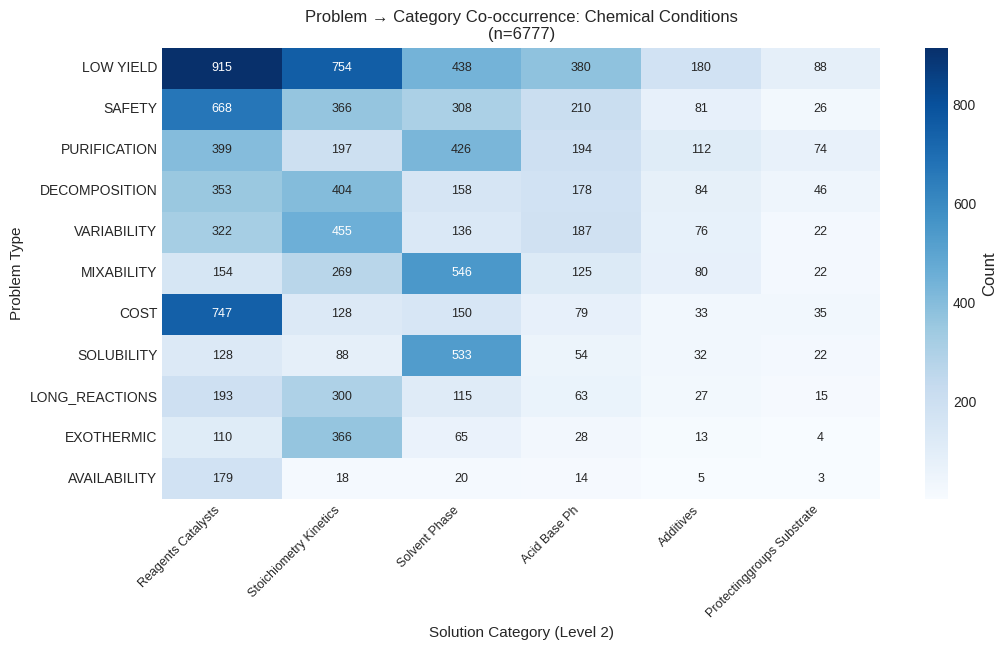

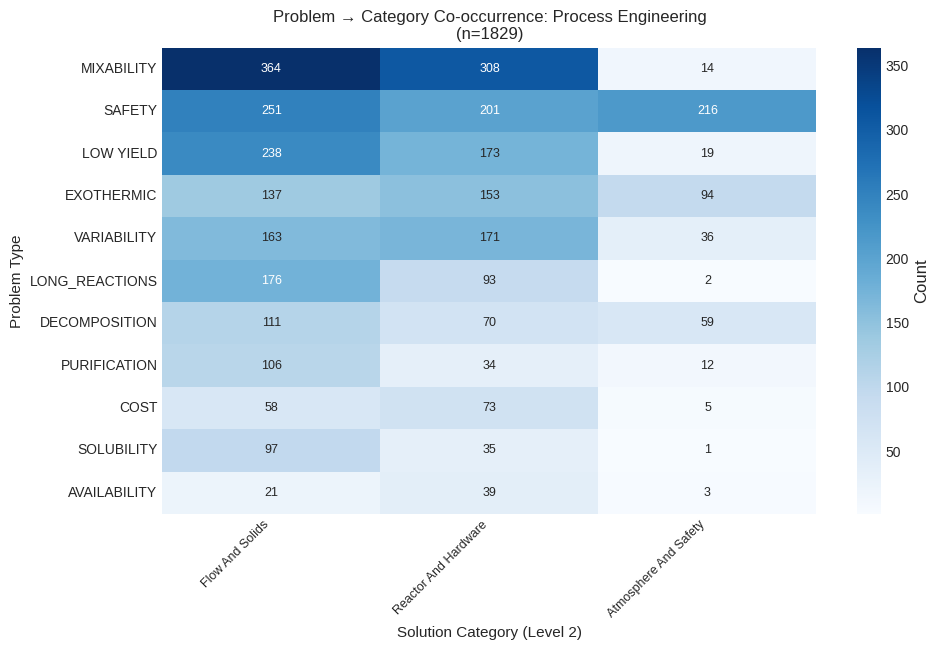

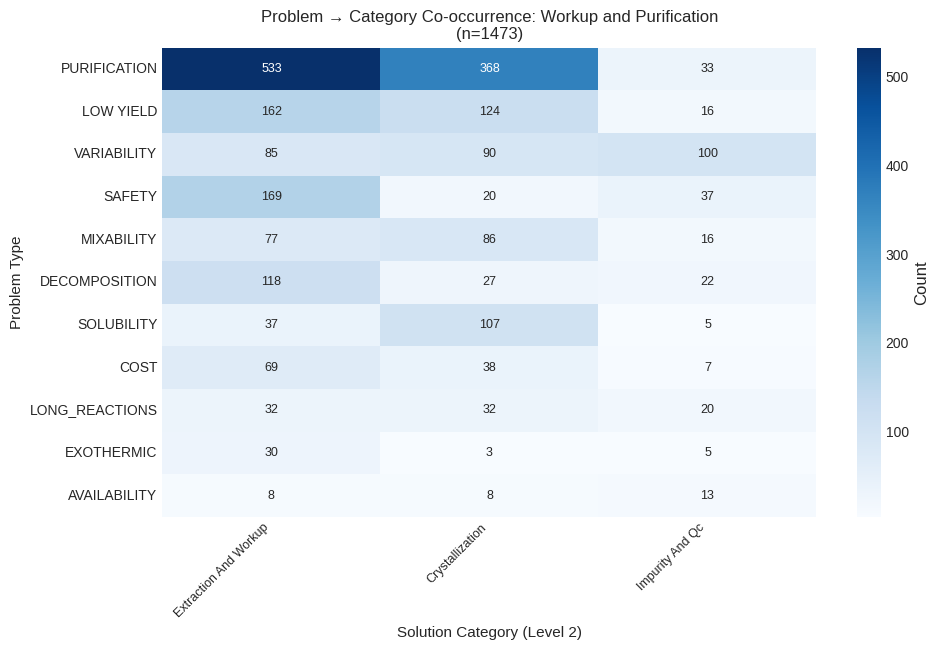

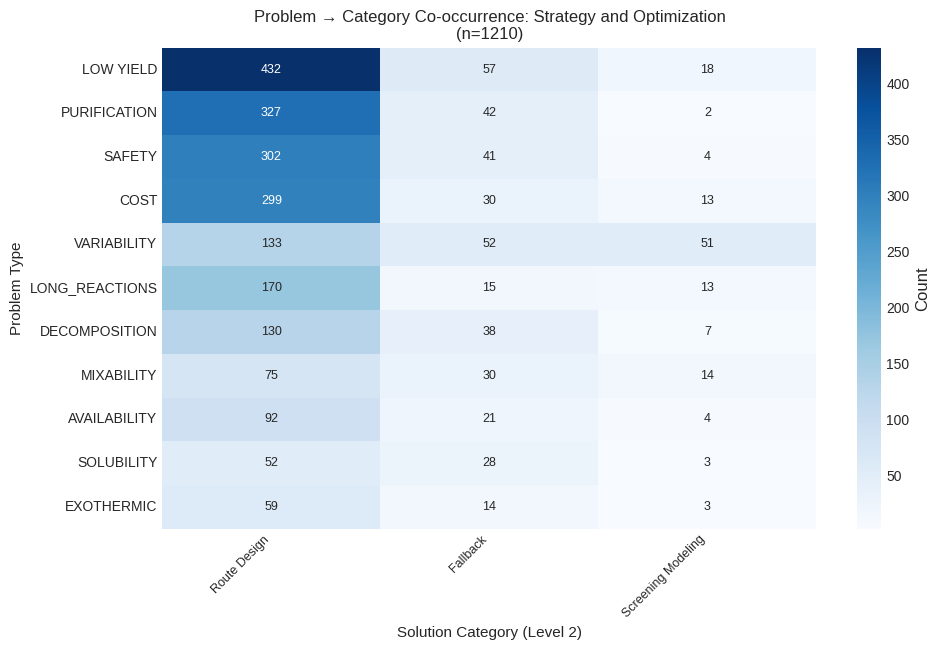

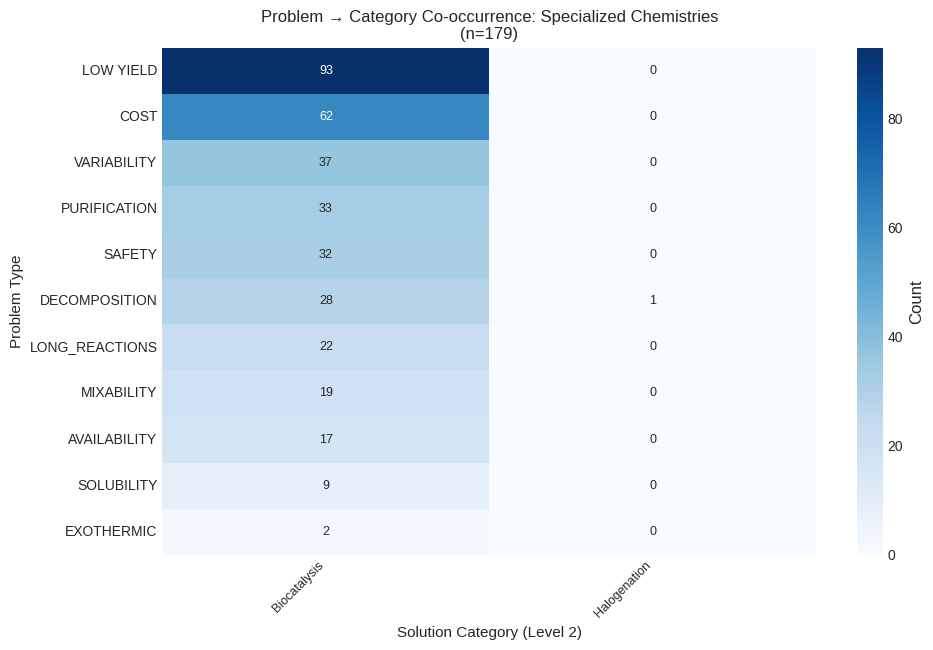

In [25]:
# Plot co-occurrence for each domain
for domain in domain_df.index:
    fig = plot_domain_category_cooccurrence(merged_df, domain, min_count=3)
    if fig:
        safe_name = domain.replace('/', '_').replace(' ', '_').lower()
        plt.savefig(f'figures/cooc_domain_{safe_name}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print()

### 4.3 Most Common Problem-Solution Pairs

In [26]:
# Find most common problem-solution pairs at all three levels
pairs = []
for _, row in merged_df.iterrows():
    if pd.notna(row['solution_domain']):
        for problem in row['problem_tags']:
            pairs.append((problem, row['solution_domain'], row['solution_category'], row['solution_leaf']))

# Domain level (Level 1)
domain_pairs = [(p, d) for p, d, _, _ in pairs]
domain_pair_counts = Counter(domain_pairs).most_common(15)

print("Top 15 Problem → Solution Domain Pairs (Level 1):")
print("-" * 60)
for (problem, domain), count in domain_pair_counts:
    print(f"{problem:20} → {domain.replace('_', ' '):30} : {count}")

# Category level (Level 2)
category_pairs = [(p, c) for p, _, c, _ in pairs]
category_pair_counts = Counter(category_pairs).most_common(20)

print("\n\nTop 20 Problem → Solution Category Pairs (Level 2):")
print("-" * 70)
for (problem, category), count in category_pair_counts:
    print(f"{problem:20} → {category.replace('_', ' '):40} : {count}")

Top 15 Problem → Solution Domain Pairs (Level 1):
------------------------------------------------------------
LOW YIELD            → Chemical Conditions            : 2755
SAFETY               → Chemical Conditions            : 1659
PURIFICATION         → Chemical Conditions            : 1402
DECOMPOSITION        → Chemical Conditions            : 1223
VARIABILITY          → Chemical Conditions            : 1198
MIXABILITY           → Chemical Conditions            : 1196
COST                 → Chemical Conditions            : 1172
PURIFICATION         → Workup and Purification        : 934
SOLUBILITY           → Chemical Conditions            : 857
LONG_REACTIONS       → Chemical Conditions            : 713
MIXABILITY           → Process Engineering            : 686
SAFETY               → Process Engineering            : 668
EXOTHERMIC           → Chemical Conditions            : 586
LOW YIELD            → Strategy and Optimization      : 507
LOW YIELD            → Process Engineering

In [27]:
# Leaf level (Level 3)
leaf_pairs = [(p, l) for p, _, _, l in pairs]
leaf_pair_counts = Counter(leaf_pairs).most_common(25)

print("Top 25 Problem → Solution Leaf Pairs (Level 3):")
print("-" * 80)
for (problem, leaf), count in leaf_pair_counts:
    clean_leaf = leaf.replace('_', ' ')[:45]
    print(f"{problem:20} → {clean_leaf:45} : {count}")

Top 25 Problem → Solution Leaf Pairs (Level 3):
--------------------------------------------------------------------------------
SOLUBILITY           → solvent change for solubility                 : 355
LOW YIELD            → change of primary reagent                     : 329
LOW YIELD            → entirely new route or step replacement        : 327
MIXABILITY           → solvent change for solubility                 : 319
LOW YIELD            → change of catalyst or ligand identity         : 284
PURIFICATION         → improved impurity purge or byproduct control  : 272
PURIFICATION         → crystallization solvent or antisolvent optimi : 259
SAFETY               → entirely new route or step replacement        : 259
COST                 → entirely new route or step replacement        : 251
LOW YIELD            → temperature setpoint or temperature ramp opti : 240
LOW YIELD            → optimization of reagent stoichiometry         : 235
SAFETY               → change of primary reage

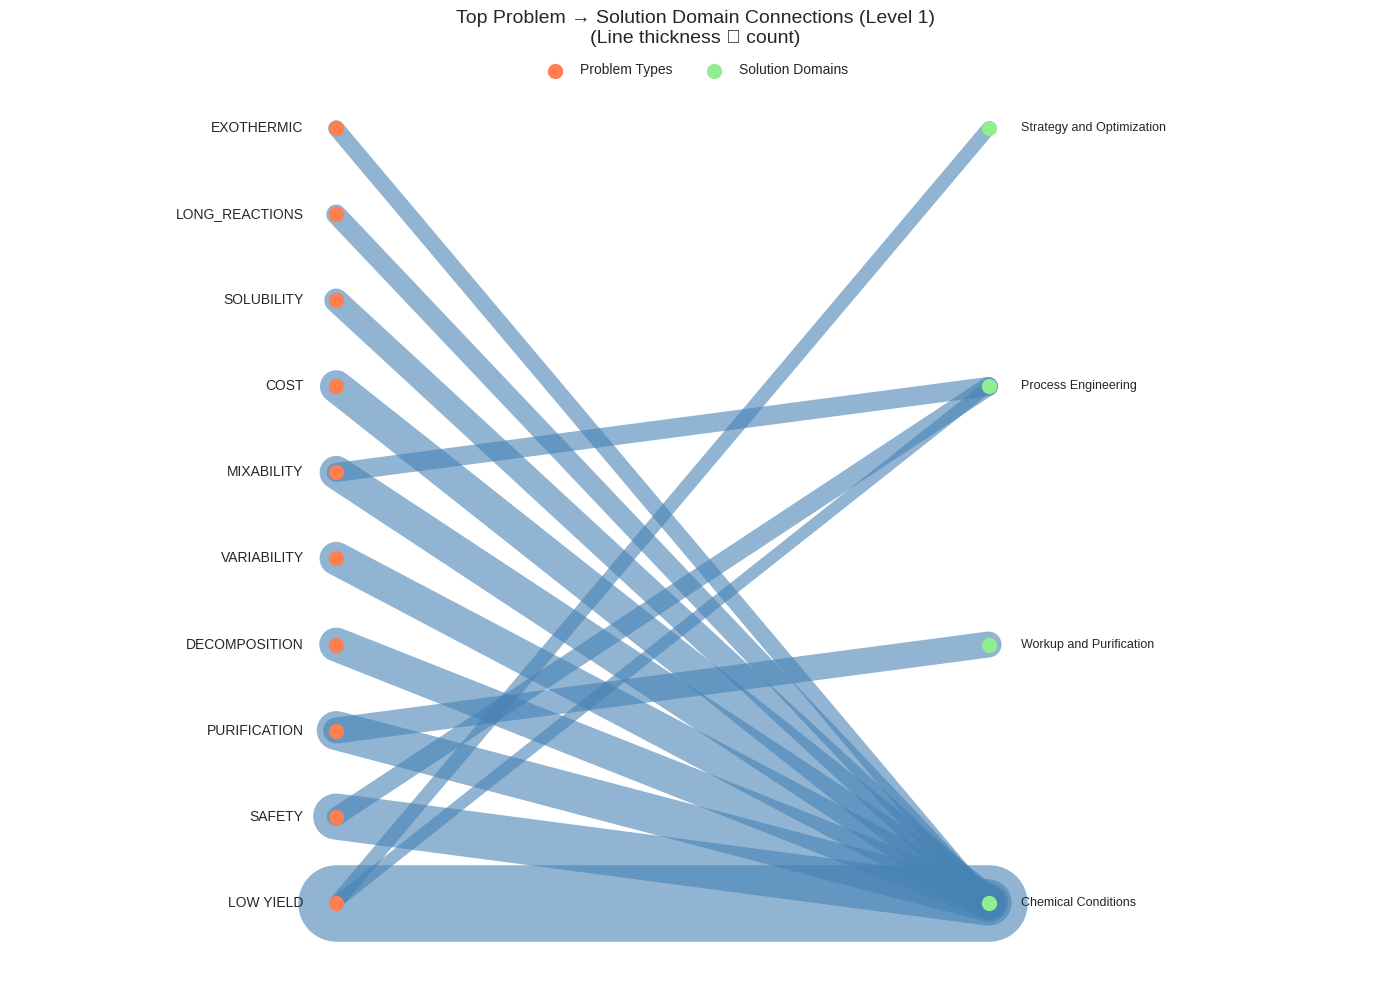

In [28]:
# Visualize top pairs as a network-style plot (Problem → Domain)
fig, ax = plt.subplots(figsize=(14, 10))

# Take top 15 domain pairs
top_pairs = domain_pair_counts[:15]

# Create a simple Sankey-like visualization
problems = [p for p, s in [pair[0] for pair in top_pairs]]
solutions = [s for p, s in [pair[0] for pair in top_pairs]]
counts = [c for _, c in top_pairs]

# Unique items
unique_problems = list(dict.fromkeys(problems))
unique_solutions = list(dict.fromkeys(solutions))

# Create positions
prob_y = {p: i for i, p in enumerate(unique_problems)}
sol_y = {s: i for i, s in enumerate(unique_solutions)}

# Scale y positions
max_prob = len(unique_problems) - 1
max_sol = len(unique_solutions) - 1

for (problem, solution), count in top_pairs:
    p_y = prob_y[problem] / max(max_prob, 1)
    s_y = sol_y[solution] / max(max_sol, 1)

    ax.plot([0, 1], [p_y, s_y],
            linewidth=count/50,
            alpha=0.6,
            color='steelblue')

# Add labels
for problem, y_idx in prob_y.items():
    y_pos = y_idx / max(max_prob, 1)
    ax.text(-0.05, y_pos, problem, ha='right', va='center', fontsize=10)
    ax.scatter(0, y_pos, s=100, c='coral', zorder=5)

for solution, y_idx in sol_y.items():
    y_pos = y_idx / max(max_sol, 1)
    ax.text(1.05, y_pos, solution.replace('_', ' '), ha='left', va='center', fontsize=9)
    ax.scatter(1, y_pos, s=100, c='lightgreen', zorder=5)

ax.set_xlim(-0.5, 1.6)
ax.set_ylim(-0.1, 1.1)
ax.axis('off')
ax.set_title('Top Problem → Solution Domain Connections (Level 1)\n(Line thickness ∝ count)', fontsize=14)

# Add legend
ax.scatter([], [], c='coral', s=100, label='Problem Types')
ax.scatter([], [], c='lightgreen', s=100, label='Solution Domains')
ax.legend(loc='upper center', ncol=2)

plt.tight_layout()
plt.savefig('figures/problem_solution_domain_flow.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary Statistics

In [29]:
# Summary
print("=" * 70)
print("SUMMARY STATISTICS - THREE-LEVEL ONTOLOGY")
print("=" * 70)
print(f"\nTotal problem-solution pairs: {len(merged_df)}")
print(f"Unique papers: {merged_df['Paper ID'].nunique()}")

print(f"\nProblem Types:")
print(f"  - Unique problem tags: {len(problem_df)}")
print(f"  - Most common: {problem_df.index[0]} ({problem_df['count'].iloc[0]} occurrences)")
print(f"  - Avg problems per pair: {merged_df['num_problems'].mean():.2f}")

print(f"\nThree-Level Solution Ontology:")
print(f"  Level 1 (Domains):    {merged_df['solution_domain'].nunique()} unique")
print(f"  Level 2 (Categories): {merged_df['solution_category'].nunique()} unique")
print(f"  Level 3 (Leaves):     {merged_df['solution_leaf'].nunique()} unique")

print(f"\nMost Common at Each Level:")
print(f"  Domain:   {domain_df.index[0].replace('_', ' ')} ({domain_df['count'].iloc[0]} pairs, {domain_df['percentage'].iloc[0]}%)")
print(f"  Category: {category_df.index[0].replace('_', ' ')} ({category_df['count'].iloc[0]} pairs, {category_df['percentage'].iloc[0]}%)")
print(f"  Leaf:     {leaf_df.index[0].replace('_', ' ')} ({leaf_df['count'].iloc[0]} pairs, {leaf_df['percentage'].iloc[0]}%)")

print(f"\nClassifier-Verifier Agreement: {agreement_rate*100:.1f}%")

SUMMARY STATISTICS - THREE-LEVEL ONTOLOGY

Total problem-solution pairs: 11468
Unique papers: 1704

Problem Types:
  - Unique problem tags: 11
  - Most common: LOW YIELD (4087 occurrences)
  - Avg problems per pair: 1.91

Three-Level Solution Ontology:
  Level 1 (Domains):    5 unique
  Level 2 (Categories): 17 unique
  Level 3 (Leaves):     55 unique

Most Common at Each Level:
  Domain:   Chemical Conditions (6777 pairs, 59.1%)
  Category: Reagents Catalysts (2075 pairs, 18.1%)
  Leaf:     change of primary reagent (688 pairs, 6.0%)

Classifier-Verifier Agreement: 92.9%


In [30]:
# Export summary tables for three-level hierarchy
problem_df.to_csv('tables/problem_distribution.csv')
domain_df.to_csv('tables/solution_domain_distribution.csv')
category_df.to_csv('tables/solution_category_distribution.csv')
leaf_df.to_csv('tables/solution_leaf_distribution.csv')
cooc_domain.to_csv('tables/problem_solution_domain_cooccurrence.csv')

# Export the full hierarchy mapping
hierarchy_data = []
for domain, categories in ONTOLOGY.items():
    for category, leaves in categories.items():
        for leaf in leaves:
            count = (merged_df['solution_leaf'] == leaf).sum()
            hierarchy_data.append({
                'domain': domain,
                'category': category,
                'leaf': leaf,
                'count': count
            })

hierarchy_df = pd.DataFrame(hierarchy_data)
hierarchy_df.to_csv('tables/full_ontology_hierarchy.csv', index=False)

print("Summary tables exported to 'tables/' directory:")
print("  - problem_distribution.csv")
print("  - solution_domain_distribution.csv (Level 1)")
print("  - solution_category_distribution.csv (Level 2)")
print("  - solution_leaf_distribution.csv (Level 3)")
print("  - problem_solution_domain_cooccurrence.csv")
print("  - full_ontology_hierarchy.csv")

Summary tables exported to 'tables/' directory:
  - problem_distribution.csv
  - solution_domain_distribution.csv (Level 1)
  - solution_category_distribution.csv (Level 2)
  - solution_leaf_distribution.csv (Level 3)
  - problem_solution_domain_cooccurrence.csv
  - full_ontology_hierarchy.csv
